# **Telco Customer Churn**
Focused customer retention programs.

About this Dataset

**Context:**

"Predict behavior to retain customers. You can analyze all relevant customer data and develop focused customer retention programs." [IBM Sample Data Sets]

**Content:**

Each row represents a customer, each column contains customer’s attributes described on the column Metadata.

**The data set includes:**

- **customerID:** Customer ID

- **gender:** Whether the customer is a male or a female

- **SeniorCitizen:** Whether the customer is a senior citizen or not (1, 0)

- **Partner:** Whether the customer has a partner or not (Yes, No)

- **Dependents:** Whether the customer has dependents or not (Yes, No)

- **tenure:** Number of months the customer has stayed with the company

- **PhoneService:** Whether the customer has a phone service or not (Yes, No)

- **MultipleLines:** Whether the customer has multiple lines or not (Yes, No, No phone service)

- **InternetService:** Customer’s internet service provider (DSL, Fiber optic, No)

- **OnlineSecurity:** Whether the customer has online security or not (Yes, No, No internet service)

- **OnlineBackup:** Whether the customer has online backup or not (Yes, No, No internet service)

- **DeviceProtection:** Whether the customer has device protection or not (Yes, No, No internet service)

- **TechSupport:** Whether the customer has tech support or not (Yes, No, No internet service)

- **StreamingTV:** Whether the customer has streaming TV or not (Yes, No, No internet service)

- **StreamingMovies:** Whether the customer has streaming movies or not (Yes, No, No internet service)

- **Contract:** The contract term of the customer (Month-to-month, One year, Two year)

- **PaperlessBilling:** Whether the customer has paperless billing or not (Yes, No)

- **PaymentMethod:** The customer’s payment method (Electronic check, Mailed check, Bank transfer (automatic), Credit card (automatic))

- **MonthlyCharges:** The amount charged to the customer monthly

- **TotalCharges:** The total amount charged to the customer

- **Churn:** Whether the customer churned or not (Yes or No)

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("blastchar/telco-customer-churn")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'telco-customer-churn' dataset.
Path to dataset files: /kaggle/input/telco-customer-churn


In [2]:
# Import all the necessory libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from imblearn.pipeline import Pipeline as ImbPipeline
import joblib
import warnings
warnings.filterwarnings("ignore")

In [3]:
telco_data = pd.read_csv(path + "/WA_Fn-UseC_-Telco-Customer-Churn.csv").copy()
telco_data.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
telco_data = telco_data.drop('customerID', axis=1)

In [5]:
telco_data.rename(columns={ 'gender': 'Gender', 'tenure': 'Tenure'}, inplace=True)
print("Updated column names:\n", telco_data.columns.tolist())

Updated column names:
 ['Gender', 'SeniorCitizen', 'Partner', 'Dependents', 'Tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


In [6]:
telco_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   Tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null   object 


There are 7043 instances with 21 features.
- 18 columns are categorical, 2 integere and 1 float.
- Note: Senior citizen has values 0 and 1, hence been classified as int.
Total charges has been classified as object where as it suppose to be float.

In [7]:
# Convert 'Totalcharges' to numeric, handling potential non-numeric entries
telco_data['TotalCharges'] = pd.to_numeric(telco_data['TotalCharges'], errors='coerce')

In [8]:
telco_data.describe()

,SeniorCitizen,Tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7032.000000
mean,0.162147,32.371149,64.761692,2283.300441
std,0.368612,24.559481,30.090047,2266.771362
min,0.000000,0.000000,18.250000,18.800000
25%,0.000000,9.000000,35.500000,401.450000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.850000,3794.737500
max,1.000000,72.000000,118.750000,8684.800000


- Senior citizen is actually categorical column.
- Tenure of the customer is ranging from 0 to 72 months.
- Monthly charges per customer ranging from 18.25 to 118.75 dollars.
- Total charges per customers are ranging from 18.80 to 8684.80 dollars.

In [9]:
for column in telco_data.columns:
    if telco_data[column].dtype == 'object':
        print(f"Column '{column}': {telco_data[column].unique()}")

Column 'Gender': ['Female' 'Male']
Column 'Partner': ['Yes' 'No']
Column 'Dependents': ['No' 'Yes']
Column 'PhoneService': ['No' 'Yes']
Column 'MultipleLines': ['No phone service' 'No' 'Yes']
Column 'InternetService': ['DSL' 'Fiber optic' 'No']
Column 'OnlineSecurity': ['No' 'Yes' 'No internet service']
Column 'OnlineBackup': ['Yes' 'No' 'No internet service']
Column 'DeviceProtection': ['No' 'Yes' 'No internet service']
Column 'TechSupport': ['No' 'Yes' 'No internet service']
Column 'StreamingTV': ['No' 'Yes' 'No internet service']
Column 'StreamingMovies': ['No' 'Yes' 'No internet service']
Column 'Contract': ['Month-to-month' 'One year' 'Two year']
Column 'PaperlessBilling': ['Yes' 'No']
Column 'PaymentMethod': ['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']
Column 'Churn': ['No' 'Yes']


In [10]:
telco_data.isnull().sum()

,0
Gender,0
SeniorCitizen,0
Partner,0
Dependents,0
Tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0
OnlineBackup,0


There are about 11 missing values in total charges.

In [11]:
telco_data['TotalCharges'].fillna(0, inplace=True)

In [12]:
telco_data.duplicated().sum()

np.int64(22)

In [13]:
telco_data.drop_duplicates(inplace=True)

In [14]:
telco_data['Churn'].value_counts()

,count
Churn,
No,5164
Yes,1857


## **EDA**


### Univariate analysis

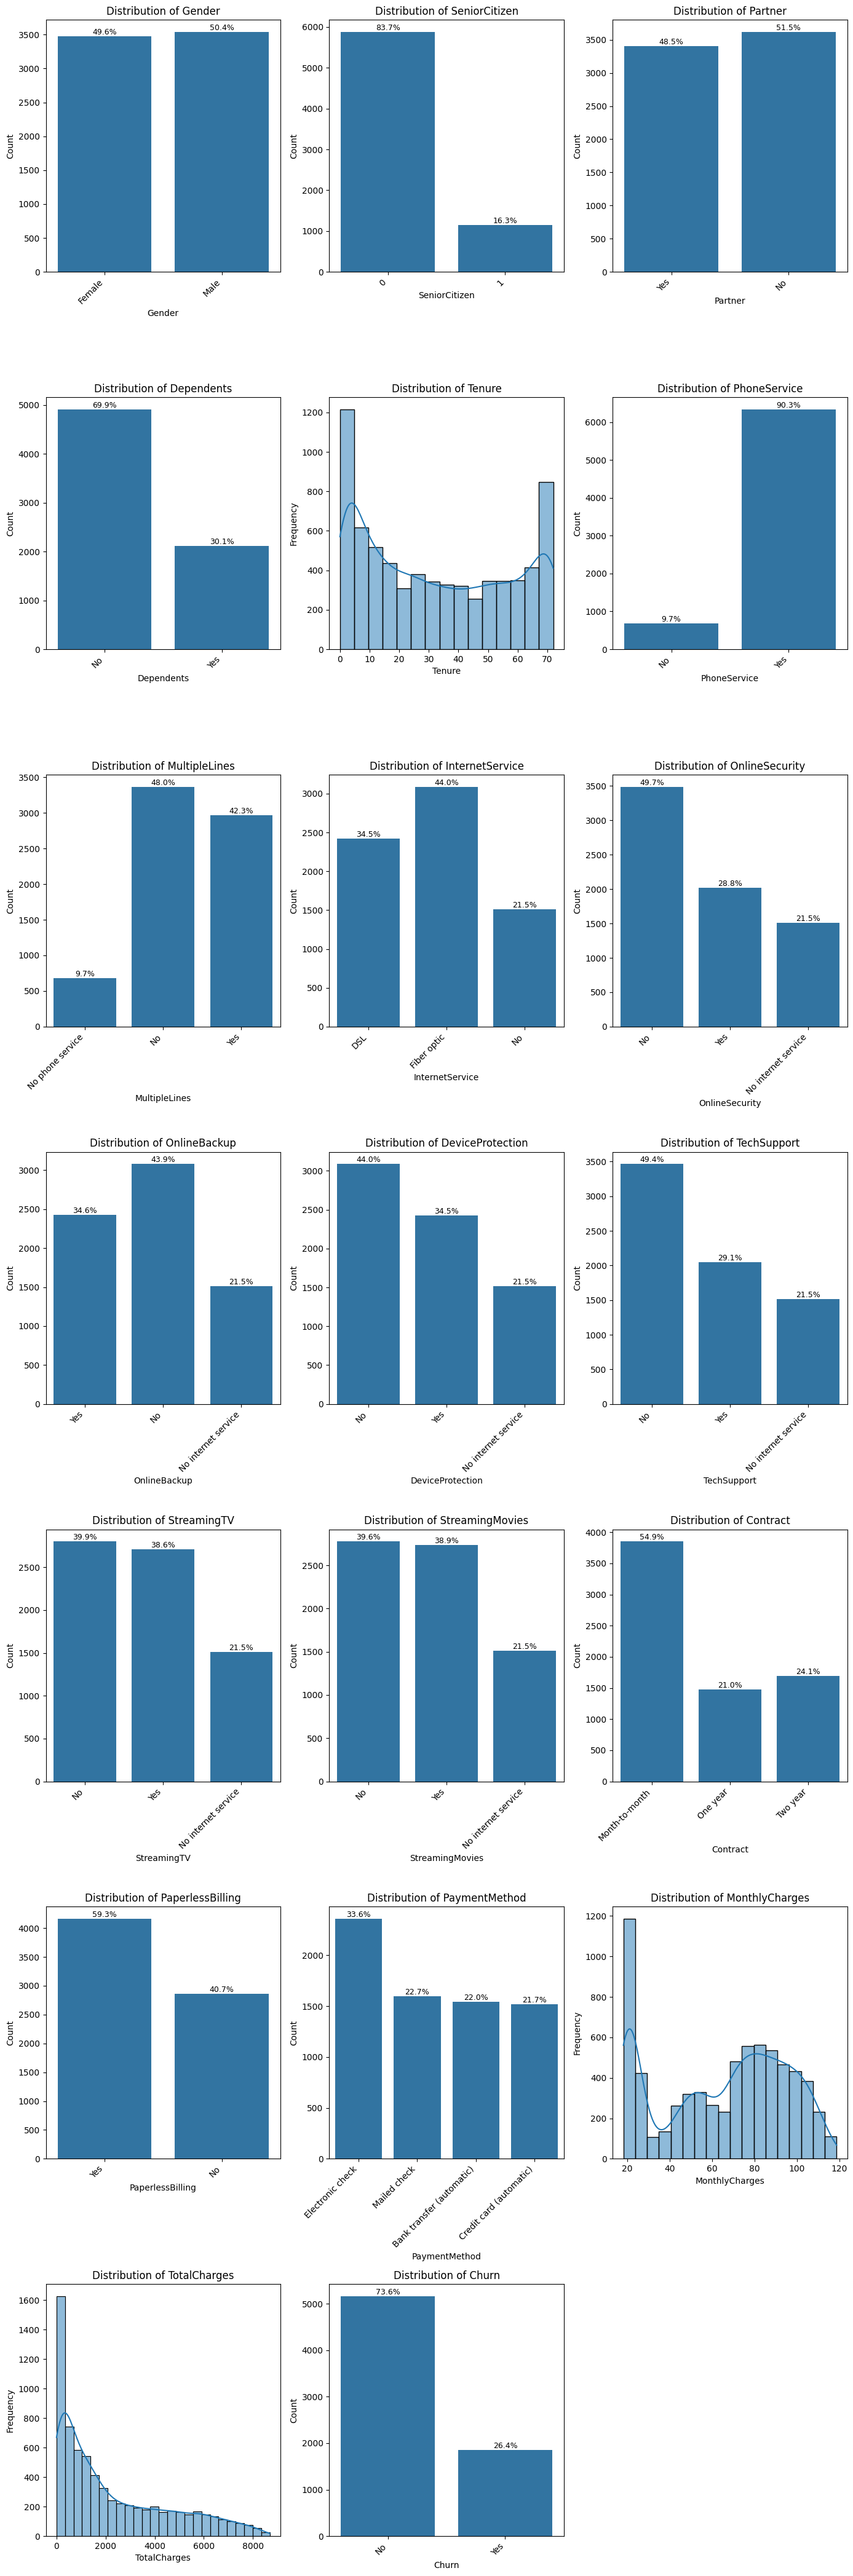

In [15]:
# Get all column names except 'Customerid' as it's a unique identifier and not useful for distribution plots
columns_to_plot = [col for col in telco_data.columns]

# Determine the number of rows needed for subplots, aiming for 3 plots per row
num_cols = len(columns_to_plot)
num_rows = (num_cols + 2) // 3  # Integer division to get enough rows

plt.figure(figsize=(14, num_rows * 6)) # Adjust figure size dynamically based on the number of plots

for i, column in enumerate(columns_to_plot):
    plt.subplot(num_rows, 3, i + 1) # Create a subplot for each column

    # Check if the column is categorical (object dtype) or the binary 'Seniorcitizen'
    if telco_data[column].dtype == 'object' or column == 'SeniorCitizen':
        ax = sns.countplot(x=column, data=telco_data)
        plt.title(f'Distribution of {column}')
        plt.xlabel(column)
        plt.ylabel('Count')
        plt.xticks(rotation=45, ha='right') # Rotate x-axis labels for better readability

        # Add percentages to the bars
        total = len(telco_data[column])
        for p in ax.patches:
            percentage = '{:.1f}%'.format(100 * p.get_height()/total)
            x = p.get_x() + p.get_width() / 2
            y = p.get_height()
            ax.annotate(percentage, (x, y), ha='center', va='bottom', fontsize=9)
    else: # Handle numerical columns (Tenure, Monthlycharges, Totalcharges)
        sns.histplot(x=column, data=telco_data, kde=True) # Use histplot for numerical distributions with kde
        plt.title(f'Distribution of {column}')
        plt.xlabel(column)
        plt.ylabel('Frequency')

plt.tight_layout() # Adjust subplot parameters for a tight layout
plt.show() # Display the plots


- **Gender:** It is almost equally distributed for male and female.
- **Senior citizen:** There are little over 1000 senior citizen as a customer.
- **Partner:** This is also very similar in both category yes and no.
- **Dependents:** only about 2000 customers have dependents out of 7000.
- **Tenure:** about 1200 customers are new since the tenure is 0, followed by little over 800 customers having tenure of 70 months. In between these, the number of customer range from 300 - 600.
- **Phone Service:** Only about 700 of the customers do not have the phone service.
- **Multiple Lines:** About 3400 customers do not have multiple lines, about 2900 have multiple lines. 700 do not have phone service.
- **Internet service:** About 3000 customers have Fiber optic, 2400 of all customers have DSL. 1500 of the customers do not have internet connection.
- **Online Security:** About 3500 customers do not have online security, around 2000 customer have online security.
- **Online Backup:** 2400 of all customers have online backup. Around 3000 customers do not have online back up.
- **Device Protection:** 2400 of all customers have device protection. Around 3000 customers do not have it.
- **Tech Support:** About 3500 do not have a tech support, about 2000 of all customers have tech support.
- **Streaming TV:** About 2700 customers do not have streaming TV service and 2600 of all have streaming Tv service.
- **Streaming Movie:** Same as streaming tv, about 2700 customers do not have streaming TV service and 2600 of all have streaming Tv service.
- **Distribution of contract:** 3900 customers are bound in month to month cotract, about 1500 have one year contract and almost 1700 have two years contract.
- **Paperless Billing:** About 4200 customers have paperless billing.
- **Payment Method:** About 2400 customers are using Electronic check, and for payment categories mailed check, bank transfer and credit card have equal amont of the customers which is about 1500.   
- **Churn:** About 2000 customers have curned.

### Bivariate Analysis

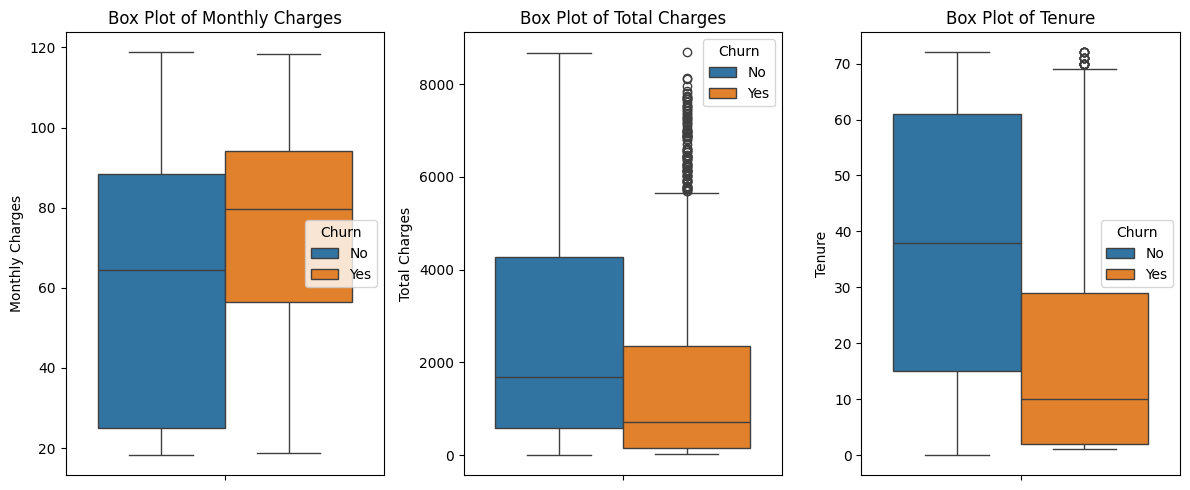

In [16]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 3, 1)
sns.boxplot(y=telco_data['MonthlyCharges'], hue = telco_data['Churn'])
plt.title('Box Plot of Monthly Charges')
plt.ylabel('Monthly Charges')

plt.subplot(1, 3, 2)
sns.boxplot(y=telco_data['TotalCharges'], hue = telco_data['Churn'])
plt.title('Box Plot of Total Charges')
plt.ylabel('Total Charges')

plt.subplot(1, 3, 3)
sns.boxplot(y=telco_data['Tenure'], hue = telco_data['Churn'])
plt.title('Box Plot of Tenure')
plt.ylabel('Tenure')

plt.tight_layout()
plt.show()

- Median value of monthly charges are 80 for the customers who has churn, most of the values are ranging from 60 to 95.
- Total charges, we have a lot of outliers. median value for total charges who has churn is around 700. It is highly right skewed.
- The median value for the amount that customer has stayed is approx 38 months for those who hasn't churn and aroud 10 for churned once. Althogh we have some outliers on th higher end for churned customers.  

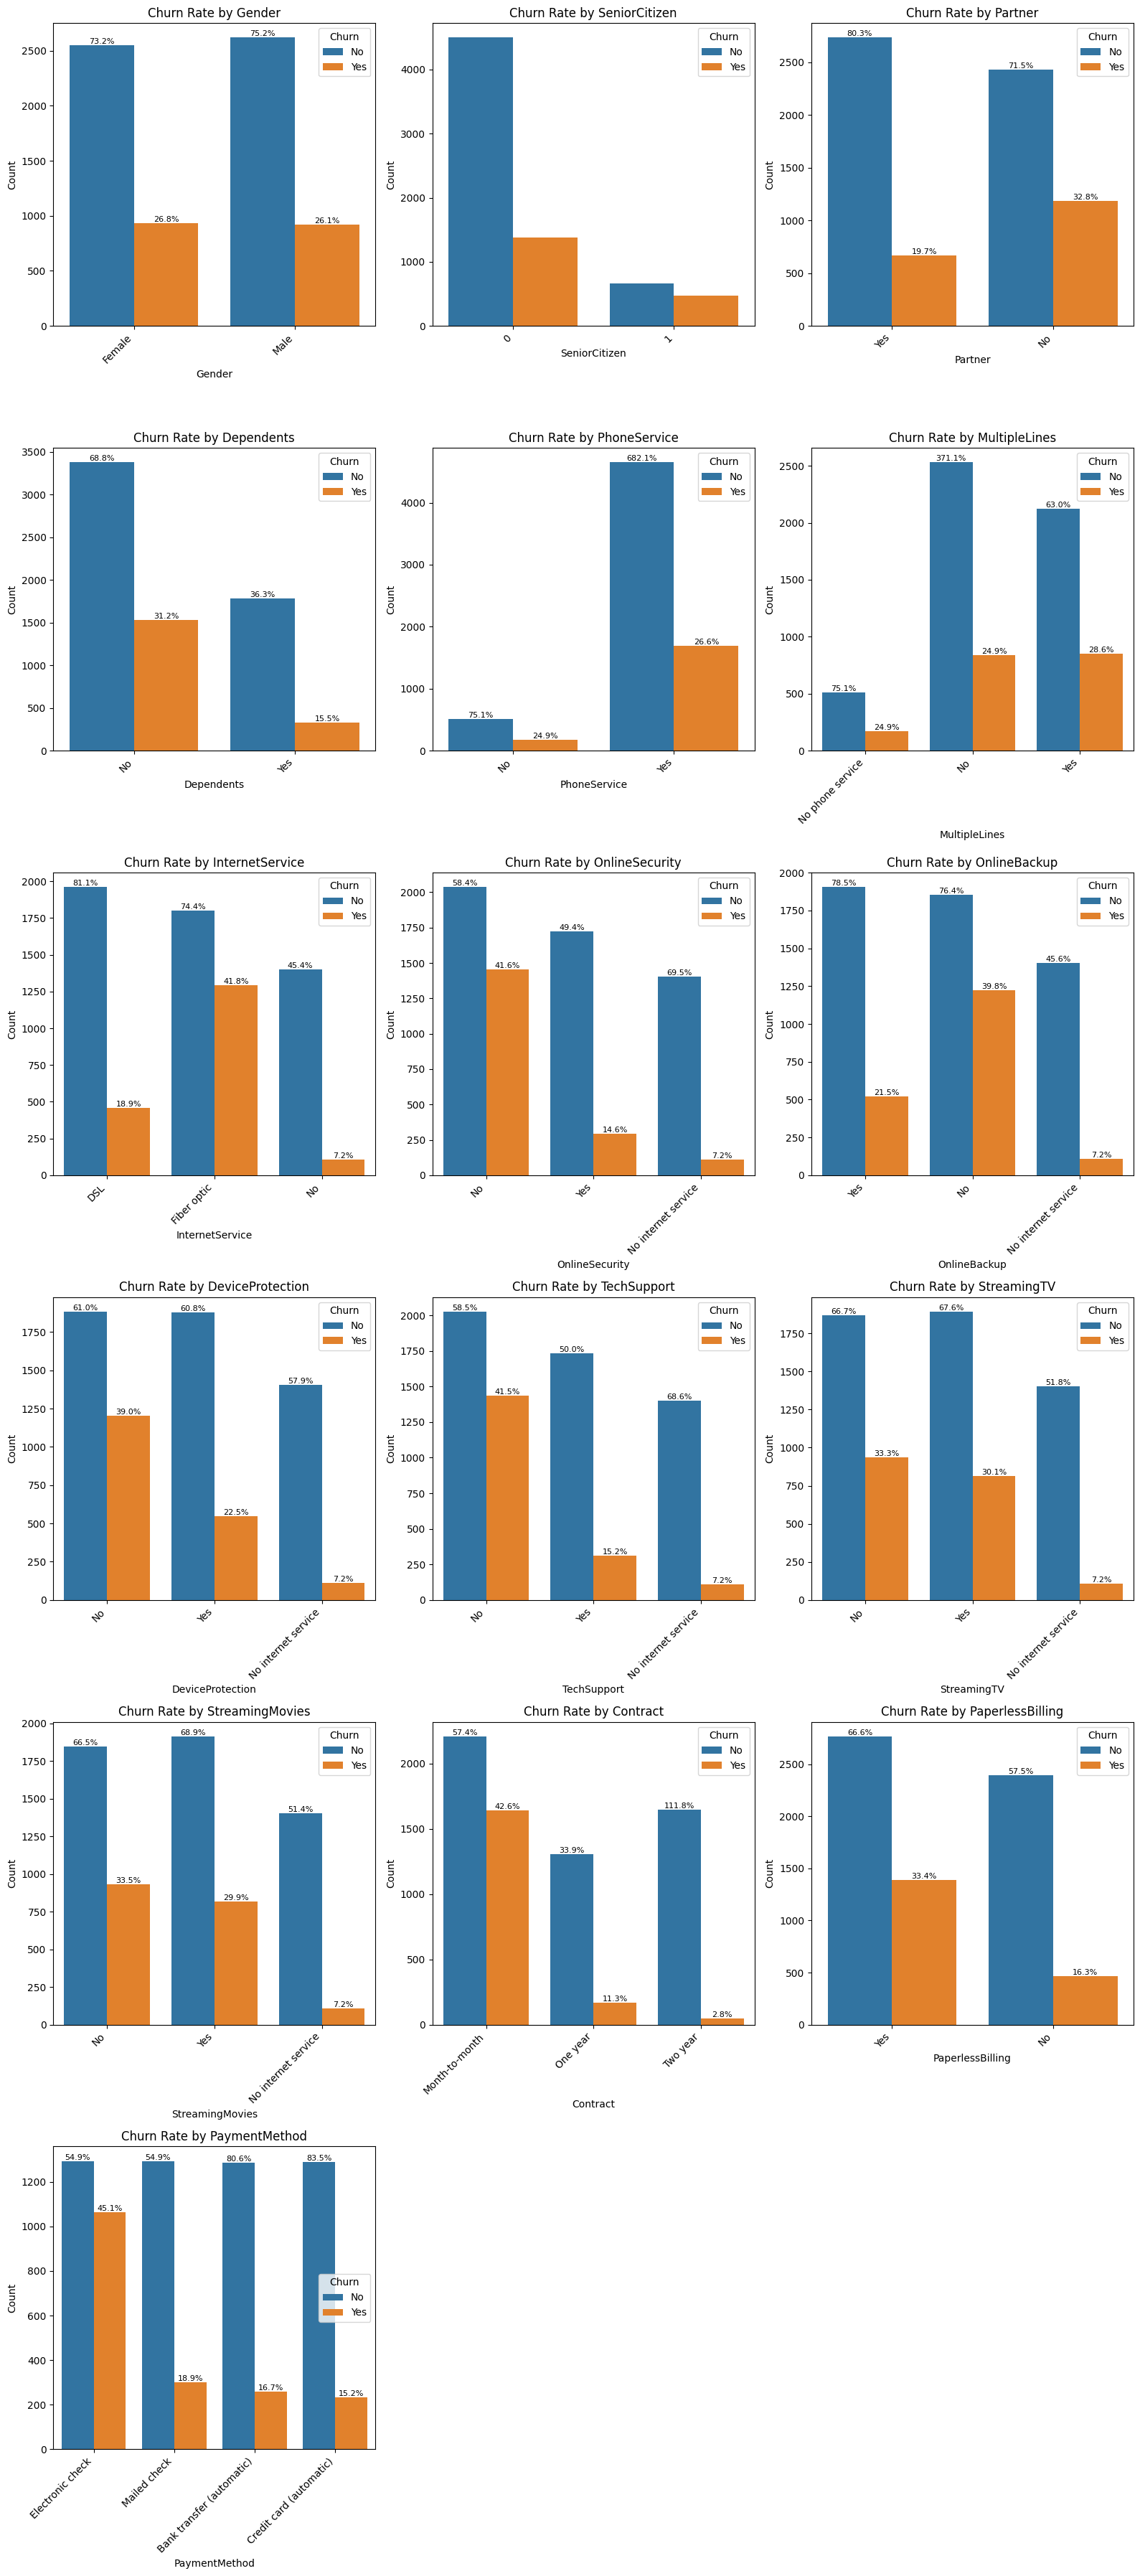

In [17]:
columns_for_countplot = [
    'Gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService',
    'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
    'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
    'Contract', 'PaperlessBilling', 'PaymentMethod'
]

# Determine the number of rows needed for subplots, aiming for 3 plots per row
num_cols = len(columns_for_countplot)
num_rows = (num_cols + 2) // 3  # Integer division to get enough rows

plt.figure(figsize=(16, num_rows * 6))

for i, column in enumerate(columns_for_countplot):
    plt.subplot(num_rows, 3, i + 1)
    ax = sns.countplot(x=column, hue='Churn', data=telco_data)
    plt.title(f'Churn Rate by {column}')
    plt.xlabel(column)
    plt.ylabel('Count')
    plt.xticks(rotation=45, ha='right')

    # Get total counts for each x-category (e.g., for 'Gender', this would be counts for 'Male' and 'Female')
    total_counts_per_x_category = telco_data[column].value_counts()

    for container in ax.containers:
        for p in container.patches:
            height = p.get_height()
            x = p.get_x() + p.get_width() / 2
            y = p.get_y() + height

            # Get the x-category label for the current bar
            # The x-axis tick labels correspond to the categories
            # Use a robust way to get the label, especially important for numerical x-axes or complex labels
            category_index = int(p.get_x() + p.get_width() / 2)
            if 0 <= category_index < len(ax.get_xticklabels()):
                x_category_label = ax.get_xticklabels()[category_index].get_text()
            else:
                x_category_label = None # Handle cases where index might be out of bounds

            # Get the total count for this specific x-category
            if x_category_label is not None:
                total_for_this_x_category = total_counts_per_x_category.get(x_category_label, 0)
            else:
                total_for_this_x_category = 0

            if total_for_this_x_category > 0:
                percentage_value = (height / total_for_this_x_category) * 100
                percentage_text = f'{percentage_value:.1f}%'
            else:
                percentage_text = ''

            # Annotate with percentage
            ax.annotate(percentage_text, (x, y), ha='center', va='bottom', fontsize=8, color='black') # Added color for visibility

plt.tight_layout()
plt.show()

- We have similar distribution for female and male who has churn.
- Around 1400 churned customers are not senior citizens.
- Churn customers are almost double in the number who do not have partner compared to who have partners.
- About 1500 churned customers do not have dependents.
- About 1800 churned customers are with phone service. Assuming issues with connection.
- The number of churn customer are equal with single and multiple lines.
- About 1300 churn customers had fiber optic as a internet service, and around 400 with DSL. Assuming issues with Fiber optic connection / service.
- About 1400 churn customer did not had online security.
- About 1400 churn customer did not had online backup.
- About 1200 churn customer did not had device protection.
- About 1400 churn customer did not had Tech support.
- Number of churn customer with and without streaming tv and steaming movies are close.
- About 1600 churn customers were on month-to-month contract.
- About 1400 churn customer had paperless billing.
- About 1050 churn customer used to pay through electronic check.

In [18]:
# Map 'Churn' target variable to 0 and 1
# It's important to work on a copy of telco_data if you don't want to permanently modify the global telco_data.
telco_data_cleaned = telco_data.copy()
telco_data_cleaned['Churn'] = telco_data_cleaned['Churn'].map({'Yes': 1, 'No': 0})



In [19]:
telco_data_cleaned['Churn'].value_counts()

,count
Churn,
0,5164
1,1857


In [20]:
# Separate features (X_raw for preprocessing) and target (y)
X_raw = telco_data_cleaned.drop('Churn', axis=1)
y = telco_data_cleaned['Churn']

print("Raw features (X_raw) and target (y) derived.")

Raw features (X_raw) and target (y) derived.


In [21]:
y.isnull().sum()

np.int64(0)

In [22]:
print(f"Original features: {len(X_raw.columns)}")

Original features: 19


In [23]:
# Identify numerical features for scaling
numerical_features = ['Tenure', 'MonthlyCharges', 'TotalCharges']

# Identify categorical features for one-hot encoding
categorical_features = X_raw.select_dtypes(include='object').columns.tolist()

# Create a ColumnTransformer for preprocessing (this will be part of the pipeline)
# One-hot encode categorical features (dropping the first column) and standard scale numerical features
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), categorical_features)
    ],
    remainder='passthrough' # Keep 'SeniorCitizen' as is since it's already 0/1 and not scaled/OHE
)

# Split the data into training and testing sets (raw data)
X_train, X_test, y_train, y_test = train_test_split(X_raw, y, test_size=0.2, random_state=89)

print("Data split into raw training and testing sets.")
print(f"X_train raw shape: {X_train.shape}")
print(f"X_test raw shape: {X_test.shape}")


Data split into raw training and testing sets.
X_train raw shape: (5616, 19)
X_test raw shape: (1405, 19)


In [25]:
# The preprocessor will now be saved as part of the full pipeline if needed,
# but for individual preprocessor saving, it's good practice to save it after fitting once.
joblib.dump(preprocessor, 'preprocessor.pkl')
print("Preprocessor pipeline saved as 'preprocessor.pkl'")

Preprocessor pipeline saved as 'preprocessor.pkl'


In [26]:
X_train.head()

,Gender,SeniorCitizen,Partner,Dependents,Tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
107,Female,0,No,No,32,No,No phone service,DSL,Yes,No,No,No,No,No,One year,No,Mailed check,30.15,927.65
6278,Female,0,Yes,No,70,Yes,Yes,Fiber optic,No,No,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),104.30,7188.50
2821,Male,1,Yes,No,1,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,74.40,74.40
5352,Male,0,No,No,26,Yes,No,Fiber optic,No,No,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,98.65,2537.00
4727,Male,0,Yes,No,60,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,Yes,Bank transfer (automatic),20.50,1198.80


In [27]:
X_test.head()

,Gender,SeniorCitizen,Partner,Dependents,Tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
6327,Male,0,No,No,28,Yes,No,Fiber optic,No,Yes,No,Yes,Yes,No,One year,Yes,Bank transfer (automatic),91.25,2483.65
458,Male,0,Yes,No,2,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Mailed check,20.00,38.00
2272,Male,0,No,Yes,1,Yes,No,DSL,No,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,49.85,49.85
2885,Male,1,No,No,67,Yes,Yes,Fiber optic,Yes,Yes,Yes,Yes,Yes,Yes,Two year,Yes,Credit card (automatic),116.10,7839.85
2280,Female,1,No,No,8,Yes,Yes,Fiber optic,No,No,No,Yes,Yes,Yes,Month-to-month,Yes,Credit card (automatic),100.15,908.55


In [28]:
# Define the preprocessor from the previous cell
# (It has already identified numerical and categorical features based on X_raw)

pipelines = {
    "logistic_regression": ImbPipeline([
        ("preprocessor", preprocessor),
        ("smote", SMOTE(random_state=89)), # SMOTE applied only to training data in pipeline
        ("model", LogisticRegression(random_state=89))
    ]),
    "random_forest": ImbPipeline([
        ("preprocessor", preprocessor),
        ("smote", SMOTE(random_state=89)),
        ("model", RandomForestClassifier(random_state=89))
    ]),
    "xgboost": ImbPipeline([
        ("preprocessor", preprocessor),
        ("smote", SMOTE(random_state=89)),
        ("model", xgb.XGBClassifier(random_state=89, use_label_encoder=False, eval_metric='logloss'))
    ])
}

print("Pipelines created, including preprocessor and SMOTE for each model.")

Pipelines created, including preprocessor and SMOTE for each model.


In [31]:
from sklearn.metrics import classification_report
from sklearn.model_selection import GridSearchCV
from imblearn.pipeline import Pipeline as ImbPipeline

print("--- Evaluating Original Pipelines ---")
for name, pipeline in pipelines.items():
    # Fit the entire pipeline (preprocessing, smote, and model) on the raw training data
    pipeline.fit(X_train, y_train)

    # Make predictions on the raw test data
    y_pred = pipeline.predict(X_test)

    # Evaluate the pipeline using a classification report
    report = classification_report(y_test, y_pred)

    print(f"\n--- {name} ---")
    print("Classification Report:\n", report)

print("\n\n--- Performing Hyperparameter Tuning for Random Forest and XGBoost ---")

# --- Random Forest Hyperparameter Tuning within pipeline ---
print("\n--- Random Forest Tuning ---")
# Get the original Random Forest pipeline
rf_pipeline = pipelines["random_forest"]

# Define the hyperparameter grid for Random Forest model within the pipeline
param_grid_rf = {
    'model__n_estimators': [100, 200, 300],
    'model__max_depth': [None, 10, 20],
    'model__min_samples_split': [2, 5, 10]
}

# Initialize GridSearchCV, wrapping the ImbPipeline
grid_search_rf_pipeline = GridSearchCV(rf_pipeline, param_grid_rf, cv=5, scoring='recall', n_jobs=-1, verbose=1)

# Fit GridSearchCV to the training data
grid_search_rf_pipeline.fit(X_train, y_train)

# Print the best parameters and best score
print(f"Best parameters for Random Forest: {grid_search_rf_pipeline.best_params_}")
print(f"Best cross-validation recall for Random Forest: {grid_search_rf_pipeline.best_score_:.4f}")

# Evaluate the best Random Forest model from the tuned pipeline on the test set
best_rf_model_pipeline = grid_search_rf_pipeline.best_estimator_
y_pred_best_rf_pipeline = best_rf_model_pipeline.predict(X_test)

report_best_rf_pipeline = classification_report(y_test, y_pred_best_rf_pipeline)
print("\nTunned Classification Report (Random Forest):\n", report_best_rf_pipeline)

# --- XGBoost Hyperparameter Tuning within pipeline ---
print("\n--- XGBoost Tuning ---")
# Get the original XGBoost pipeline
xgb_pipeline = pipelines["xgboost"]

# Define the hyperparameter grid for XGBoost model within the pipeline
param_grid_xgb = {
    'model__n_estimators': [100, 200, 300],
    'model__max_depth': [3, 5, 7],
    'model__learning_rate': [0.01, 0.1, 0.2],
    'model__subsample': [0.7, 0.9],
    'model__colsample_bytree': [0.7, 0.9]
}

# Initialize GridSearchCV, wrapping the ImbPipeline
grid_search_xgb_pipeline = GridSearchCV(xgb_pipeline, param_grid_xgb, cv=5, scoring='recall', n_jobs=-1, verbose=1)

# Fit GridSearchCV to the training data
grid_search_xgb_pipeline.fit(X_train, y_train)

# Print the best parameters and best score
print(f"Best parameters for XGBoost: {grid_search_xgb_pipeline.best_params_}")
print(f"Best cross-validation recall for XGBoost: {grid_search_xgb_pipeline.best_score_:.4f}")

# Evaluate the best XGBoost model from the tuned pipeline on the test set
best_xgb_model_pipeline = grid_search_xgb_pipeline.best_estimator_
y_pred_best_xgb_pipeline = best_xgb_model_pipeline.predict(X_test)

report_best_xgb_pipeline = classification_report(y_test, y_pred_best_xgb_pipeline)
print("\nTunned Classification Report (XGBoost):\n", report_best_xgb_pipeline)


--- Evaluating Original Pipelines ---

--- logistic_regression ---
Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.74      0.81      1058
           1       0.49      0.76      0.59       347

    accuracy                           0.74      1405
   macro avg       0.70      0.75      0.70      1405
weighted avg       0.80      0.74      0.76      1405


--- random_forest ---
Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.86      0.86      1058
           1       0.58      0.57      0.57       347

    accuracy                           0.79      1405
   macro avg       0.72      0.72      0.72      1405
weighted avg       0.79      0.79      0.79      1405


--- xgboost ---
Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.87      0.86      1058
           1       0.58      0.57      0.58       347

   

## **AUC-ROC Curve Comparison**

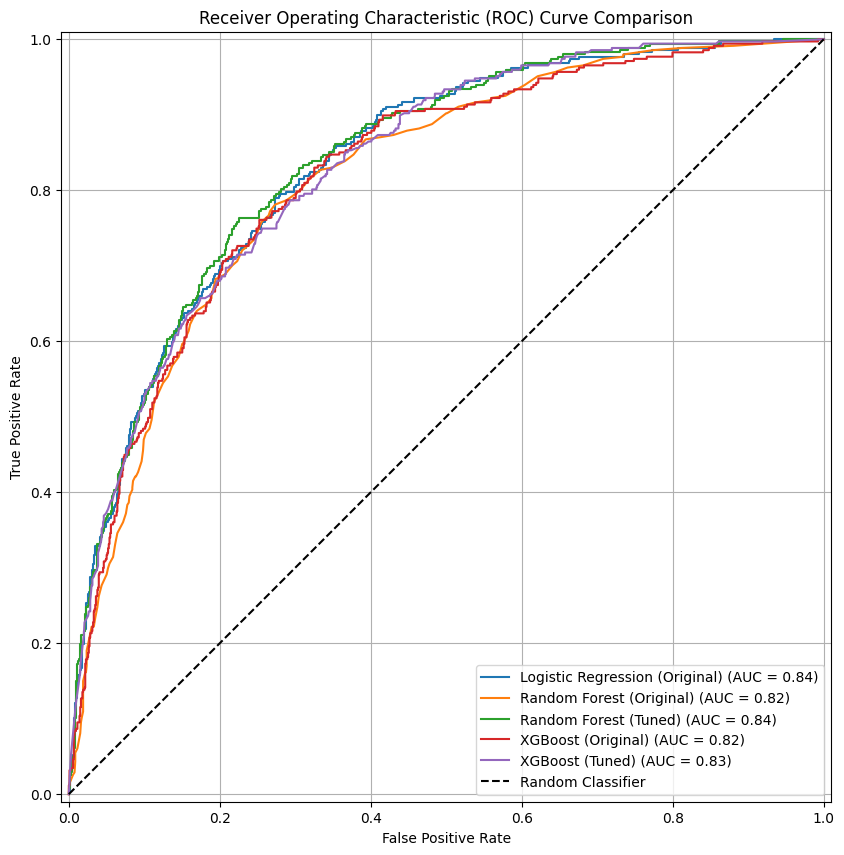

In [32]:
from sklearn.metrics import RocCurveDisplay, roc_curve, auc
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 10))

# --- Plot ROC for Original Logistic Regression ---
# Predict probabilities using the fitted pipeline
y_pred_proba_lr = pipelines["logistic_regression"].predict_proba(X_test)[:, 1]
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_pred_proba_lr)
auc_lr = auc(fpr_lr, tpr_lr)
RocCurveDisplay(fpr=fpr_lr, tpr=tpr_lr, roc_auc=auc_lr, estimator_name='Logistic Regression (Original)').plot(ax=plt.gca())

# --- Plot ROC for Original Random Forest ---
# Predict probabilities using the fitted pipeline
y_pred_proba_rf_orig = pipelines["random_forest"].predict_proba(X_test)[:, 1]
fpr_rf_orig, tpr_rf_orig, _ = roc_curve(y_test, y_pred_proba_rf_orig)
auc_rf_orig = auc(fpr_rf_orig, tpr_rf_orig)
RocCurveDisplay(fpr=fpr_rf_orig, tpr=tpr_rf_orig, roc_auc=auc_rf_orig, estimator_name='Random Forest (Original)').plot(ax=plt.gca())

# --- Plot ROC for Tuned Random Forest ---
# Predict probabilities using the best estimator from GridSearchCV
y_pred_proba_rf_tuned = grid_search_rf_pipeline.best_estimator_.predict_proba(X_test)[:, 1]
fpr_rf_tuned, tpr_rf_tuned, _ = roc_curve(y_test, y_pred_proba_rf_tuned)
auc_rf_tuned = auc(fpr_rf_tuned, tpr_rf_tuned)
RocCurveDisplay(fpr=fpr_rf_tuned, tpr=tpr_rf_tuned, roc_auc=auc_rf_tuned, estimator_name='Random Forest (Tuned)').plot(ax=plt.gca())

# --- Plot ROC for Original XGBoost ---
# Predict probabilities using the fitted pipeline
y_pred_proba_xgb_orig = pipelines["xgboost"].predict_proba(X_test)[:, 1]
fpr_xgb_orig, tpr_xgb_orig, _ = roc_curve(y_test, y_pred_proba_xgb_orig)
auc_xgb_orig = auc(fpr_xgb_orig, tpr_xgb_orig)
RocCurveDisplay(fpr=fpr_xgb_orig, tpr=tpr_xgb_orig, roc_auc=auc_xgb_orig, estimator_name='XGBoost (Original)').plot(ax=plt.gca())

# --- Plot ROC for Tuned XGBoost ---
# Predict probabilities using the best estimator from GridSearchCV
y_pred_proba_xgb_tuned = grid_search_xgb_pipeline.best_estimator_.predict_proba(X_test)[:, 1]
fpr_xgb_tuned, tpr_xgb_tuned, _ = roc_curve(y_test, y_pred_proba_xgb_tuned)
auc_xgb_tuned = auc(fpr_xgb_tuned, tpr_xgb_tuned)
RocCurveDisplay(fpr=fpr_xgb_tuned, tpr=tpr_xgb_tuned, roc_auc=auc_xgb_tuned, estimator_name='XGBoost (Tuned)').plot(ax=plt.gca())


plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.title('Receiver Operating Characteristic (ROC) Curve Comparison')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

### **Understanding the AUC-ROC Curve and Model Trade-offs**



#### **Comparison of Model Performance (AUC Scores):**


*   All the models demonstrate good performance, with AUC scores significantly above 0.5. This indicates they are effective at distinguishing between churning and non-churning customers.
*   **Random Forest (Tuned) and Logistic Regression (AUC = `0.84`)** appears to be the best performer based on AUC, suggesting it offers the most favorable trade-off between identifying true churners and minimizing false alarms.
*   **XGBoost (Tuned) (AUC = `0.82`)** is a strong contender, often offering a good balance of performance and computational efficiency in many real-world scenarios.
*   **Random Forest (Original) and XGBoost(Original) both (AUC = `0.82`)** provides a solid baseline with good interpretability and they are strong contender, often offering a good balance of performance and computational efficiency in many real-world scenarios.


* Considering the computing cost since random forest and logistic regeression are very close, I would like to use logistic regression model.

In [33]:
# Save the best model Logistic Regression
best_pipeline = pipelines["logistic_regression"]
joblib.dump(best_pipeline, 'log_reg_model.pkl')
print("Best model saved as 'log_reg_model.pkl'")

Best model saved as 'log_reg_model.pkl'


```
fastapi~=0.110.0
uvicorn~=0.29.0
pandas~=2.2.0
numpy~=1.26.0
scikit-learn~=1.4.0
imblearn~=0.11.0
xgboost~=2.0.0
```

To install these, you would run `pip install -r requirements.txt` in your environment.